<a href="https://colab.research.google.com/github/suleymagination/mechanistic-tomato-crop-model/blob/main/notebooks/model_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# 1. Repository Setup & Path Configuration for Google Colab
import os
import sys
from pathlib import Path

# Clone repository into Colab environment if running in cloud
repo_name = "mechanistic-tomato-crop-model"
repo_url = f"https://github.com/suleymagination/{repo_name}.git"

if not Path(repo_name).exists() and not Path("src").exists():
    !git clone {repo_url}
    os.chdir(repo_name)
elif Path(repo_name).exists():
    os.chdir(repo_name)

# Append project root to Python search path
sys.path.append(os.getcwd())

# Import custom modules directly from src/
from src.climate import ClimateDataLoader
from src.model import TomatoCropModel

print("Repository loaded successfully. Current directory:", os.getcwd())

Repository loaded successfully. Current directory: /content/mechanistic-tomato-crop-model


In [6]:
# 2. Data Loading (Supports GitHub Raw URLs and Local Paths)
import pandas as pd

# Direct raw data URLs to ensure standard execution across Colab & local environments
climate_url = "https://raw.githubusercontent.com/suleymagination/mechanistic-tomato-crop-model/main/data/greenhouse_climate.csv"
harvest_url = "https://raw.githubusercontent.com/suleymagination/mechanistic-tomato-crop-model/main/data/harvest_summary.csv"

# Load climate time-series & compute daily physiological aggregates
loader = ClimateDataLoader(climate_url)
df_climate_raw = loader.load_data()
df_daily_climate = loader.get_daily_summaries(df_climate_raw)

# Load WUR empirical validation targets
df_harvest = pd.read_csv(harvest_url)
df_harvest["harvest_date"] = pd.to_datetime(df_harvest["harvest_date"]).dt.date

In [7]:
# 3. Execute Mechanistic Model Simulation
# Compartment 3.06 parameters: dynamic plant density from dataset, LUE = 8.4 g FW/mol PAR
model = TomatoCropModel(plant_density=25.3, lue_g_mol=8.4)
df_sim = model.run_simulation(df_daily_climate)
df_sim["date"] = pd.to_datetime(df_sim["date"]).dt.date

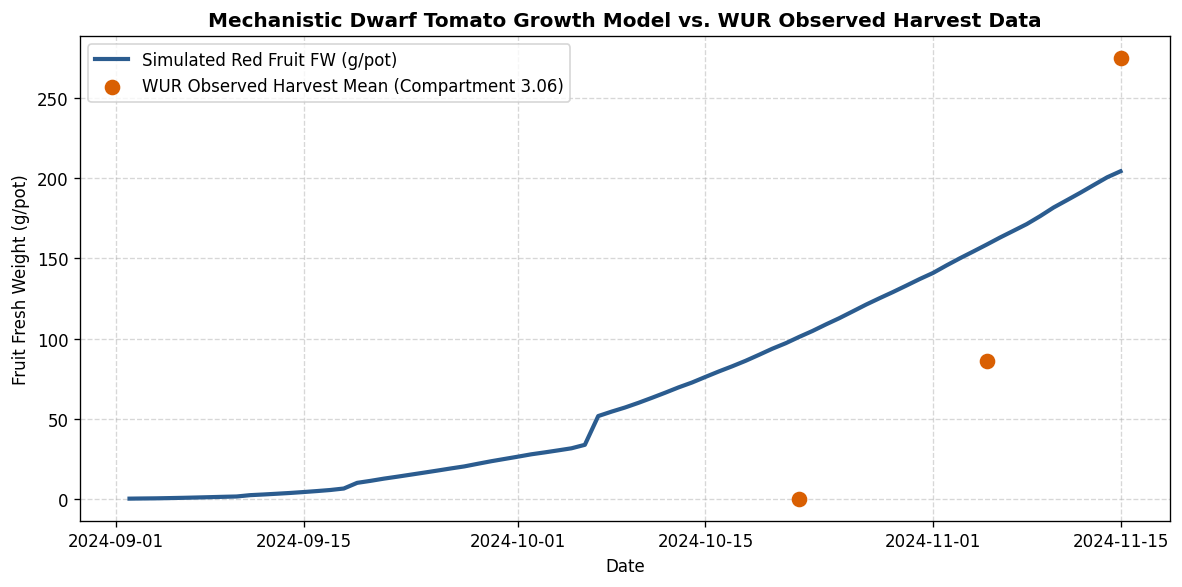

--- Simulation Summary ---


,day,date,biomass_dw_g_m2,fruit_fw_g_pot,water_use_l_m2,vpd_kpa
70,71,2024-11-11,422.32,186.42,0.23,0.37
71,72,2024-11-12,427.29,191.06,0.23,0.38
72,73,2024-11-13,432.59,195.90,0.23,0.32
73,74,2024-11-14,437.66,200.70,0.22,0.29
74,75,2024-11-15,440.41,204.48,0.14,0.28


In [8]:
# 4. Validation Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), dpi=120)

# Plot Simulated Fruit Fresh Weight
plt.plot(
    df_sim["date"],
    df_sim["fruit_fw_g_pot"],
    label="Simulated Red Fruit FW (g/pot)",
    color="#2b5c8f",
    linewidth=2.5,
)

# Aggregate WUR observed harvest mean values by date
observed_means = (
    df_harvest.groupby("harvest_date")["red_fw_g"]
    .mean()
    .reset_index()
    .dropna()
)

# Plot WUR Observed Target Values
plt.scatter(
    observed_means["harvest_date"],
    observed_means["red_fw_g"],
    color="#d95f02",
    s=70,
    zorder=5,
    label="WUR Observed Harvest Mean (Compartment 3.06)",
)

plt.title("Mechanistic Dwarf Tomato Growth Model vs. WUR Observed Harvest Data", fontsize=12, fontweight="bold")
plt.xlabel("Date", fontsize=10)
plt.ylabel("Fruit Fresh Weight (g/pot)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Display summary metrics
print("--- Simulation Summary ---")
display(df_sim.tail(5))